# Logistic Regression: Predicting Frustration from Heart Rate (HR)

This notebook builds a logistic regression model that predicts whether someone is frustrated or
not, based on the heart-rate (HR) features in `HR_data.csv`.

`Frustrated` is rated 0-8 in the data, so we convert it into a binary variable (0 = not frustrated,
1 = frustrated) using a threshold, which you can change below.

The tricky part of this dataset is that it has repeated measurements: 14 individuals, 12
measurements each (4 rounds x 3 phases). A normal random train/test split would let rows from the
same person land in both sets, so the model could partly learn to recognize the *person* instead
of the actual relationship between heart rate and frustration. To avoid that, we use nested
Leave-One-Subject-Out (LOSO) cross-validation: the outer loop holds out one individual at a time
(14 folds), and an inner `StratifiedGroupKFold` loop on the remaining 13 individuals (together with
`GridSearchCV`) picks the regularization strength `C`, `class_weight`, and the decision threshold,
all without ever touching the held-out individual. All of the preprocessing (standardizing the HR
features, one-hot encoding `Phase`/`Round`) sits inside a `Pipeline`, so it's refit separately on
each training fold and never leaks information from the test fold.

After the nested LOSO loop gives us an honest performance estimate, we also fit one final model on
all 14 individuals, using the same procedure, purely so we can look at its coefficients - that
final model isn't used for any performance numbers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    LeaveOneGroupOut,
    StratifiedGroupKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)

## 1. Load data

In [2]:
df = pd.read_csv("HR_data.csv", index_col=0)
df.head()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HR_Mean     168 non-null    float64
 1   HR_Median   168 non-null    float64
 2   HR_std      168 non-null    float64
 3   HR_Min      168 non-null    float64
 4   HR_Max      168 non-null    float64
 5   HR_AUC      168 non-null    float64
 6   Round       168 non-null    str    
 7   Phase       168 non-null    str    
 8   Individual  168 non-null    int64  
 9   Puzzler     168 non-null    int64  
 10  Frustrated  168 non-null    int64  
 11  Cohort      168 non-null    str    
dtypes: float64(6), int64(3), str(3)
memory usage: 15.9 KB


,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Individual,Puzzler,Frustrated
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.00000,168.000000,168.000000
mean,76.009226,74.821458,6.041234,67.422679,89.062024,23398.551815,7.50000,0.500000,2.291667
std,7.501301,8.101459,4.267282,7.042010,12.764559,3589.600223,4.04318,0.501495,1.924796
min,57.341463,54.130000,0.844255,52.180000,70.150000,15975.450000,1.00000,0.000000,0.000000
25%,70.952240,70.175000,3.092851,62.645000,79.752500,20805.553750,4.00000,0.000000,1.000000
50%,75.618503,74.625000,4.678773,67.540000,87.355000,22493.687500,7.50000,0.500000,2.000000
75%,80.308459,79.010000,7.281001,71.922500,94.682500,25645.200000,11.00000,1.000000,4.000000
max,96.159341,94.880000,21.880307,82.680000,137.670000,35299.460000,14.00000,1.000000,8.000000


## 2. Convert frustration into a binary variable

`Frustrated` ranges from 0 to 8 in the dataset. We choose a threshold (`threshold`), so that all values >= threshold become class 1 ("frustrated"), and all values below become class 0 ("not frustrated").

You can change `threshold` to see how the class balance and the model's performance change.


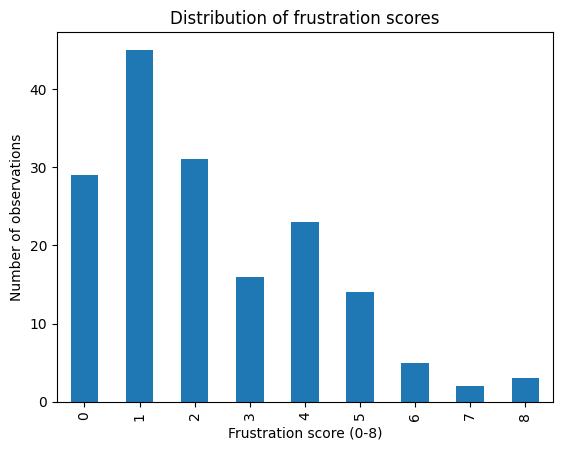

In [4]:
# Distribution of the raw frustration scores
df["Frustrated"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Frustration score (0-8)")
plt.ylabel("Number of observations")
plt.title("Distribution of frustration scores")
plt.show()


In [5]:
threshold = 3  # adjust as needed (>= threshold => frustrated = 1)

df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

print(df["Frustrated_binary"].value_counts())
print(f"\nProportion frustrated (class 1): {df['Frustrated_binary'].mean():.2%}")


Frustrated_binary
0    105
1     63
Name: count, dtype: int64

Proportion frustrated (class 1): 37.50%


## 3. Per-individual normalization of HR features

Resting heart rate and heart-rate variability differ a lot from person to person (fitness level,
age, caffeine, etc.), and that between-person variation can drown out the within-person variation
that actually relates to frustration - i.e. whether someone's heart rate is higher or lower than
*their own* normal level.

So for each HR feature we z-score it per individual: subtract that person's own mean and divide by
their own standard deviation (computed across their 12 measurements). What's left is how many
standard deviations a given measurement is from that person's normal level.

This assumes a new individual would also have a short calibration/baseline period to compute their
own mean and std from, which fits the experiment's design (each round starts with a rest phase), so
it still makes sense for predicting on people the model hasn't seen before.

In [6]:
raw_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Max", "HR_AUC"]

df_norm = df.copy()
for col in raw_feature_cols:
    df_norm[col] = df.groupby("Individual")[col].transform(lambda s: (s - s.mean()) / s.std())

df_norm[raw_feature_cols].describe()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC
count,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02
mean,6.079793e-17,-1.059999e-15,-3.700743e-17,-5.709718e-16,-6.079793e-17
std,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01
min,-2.090416e+00,-2.320427e+00,-1.561129e+00,-1.751144e+00,-1.571144e+00
25%,-7.280204e-01,-7.704507e-01,-6.933782e-01,-7.559462e-01,-6.944055e-01
50%,-2.775503e-02,-8.617163e-02,-3.165731e-01,-2.086793e-01,-2.577854e-01
75%,6.248084e-01,6.679727e-01,5.324870e-01,5.103417e-01,5.597943e-01
max,2.091565e+00,2.416027e+00,2.897812e+00,2.546851e+00,2.937623e+00


## 4. Choose features, target and groups

`HR_data.csv` has 6 HR features (`HR_Mean`, `HR_Median`, `HR_std`, `HR_Min`, `HR_Max`, `HR_AUC`).
Based on the correlation analysis in `feature_correlation_analysis.ipynb`, we use 5 of these,
dropping `HR_Min`, plus one-hot encoded `Phase` (3 levels) and `Round` (4 levels) so the model can
also learn from when a measurement was taken. The ANN notebook uses this same fixed feature set; no
automatic feature selection is applied anywhere.

X is these 5 (per-individual normalized) HR features plus `Phase`/`Round`, y is the binary
frustration label, and `groups` is `Individual`, used only to make sure a person's rows never end
up split across the training and test sets.

In [7]:
feature_cols = raw_feature_cols  # Phase/Round excluded: see justification in the report

X = df_norm[feature_cols]
y = df_norm["Frustrated_binary"]
groups = df_norm["Individual"]

X.head()

,HR_Mean,HR_Median,HR_std,HR_Max,HR_AUC
0,1.097189,1.223550,-0.030634,0.495003,-0.255968
1,-1.593119,-1.723680,-0.714876,-0.999437,-0.547102
2,-0.672146,-0.616981,-0.101523,-0.419072,-0.630037
3,1.463764,1.175950,0.555938,0.944786,0.427252
4,0.849517,-0.144948,2.204090,2.462439,0.026698


### Features used in this model

This logistic regression is trained on 10 preprocessed columns derived from the 7 columns of `X`
above - every fold's model uses all of them, no feature selection happens anywhere:

- `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`, `HR_AUC`, each z-scored per individual (Section 3)
  and then standardized again inside the pipeline's `ColumnTransformer`.
- `Phase`, one-hot encoded into `Phase_phase2`, `Phase_phase3` (`phase1` is the reference level).
- `Round`, one-hot encoded into `Round_round_2`, `Round_round_3`, `Round_round_4` (`round_1` is the
  reference level).

`HR_Min` isn't used as a predictor, and neither is `Individual` - that column only defines the LOSO
splits so no individual's rows end up in both the training and test set of a fold.

## 5. Nested Leave-One-Subject-Out (LOSO) cross-validation

This is where the LOSO loop actually runs. For each of the 14 individuals in turn: the outer loop
holds out that person's 12 rows as the test set; an inner `StratifiedGroupKFold` loop on the
remaining 13 individuals, together with `GridSearchCV`, picks `C` and `class_weight` and generates
out-of-fold probabilities for choosing the decision threshold that maximizes balanced accuracy, all without touching
the held-out person; the tuned pipeline is then refit on the 13 training individuals and evaluated
once on the held-out one.

Repeating this 14 times gives every row in the dataset exactly one out-of-fold prediction. Pooling
those 168 predictions is what we use as the honest estimate of how well this generalizes to a new
person.

In [8]:
preprocessor = ColumnTransformer([
    ("hr", StandardScaler(), raw_feature_cols),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
}

outer_cv = LeaveOneGroupOut()

oof_true = np.zeros(len(y), dtype=int)
oof_pred = np.zeros(len(y), dtype=int)
oof_proba = np.zeros(len(y), dtype=float)
fold_records = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    groups_tr = groups.iloc[train_idx]
    test_individual = groups.iloc[test_idx].iloc[0]

    # Inner CV (13 training individuals): hyperparameter tuning
    inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=inner_cv, scoring="balanced_accuracy", n_jobs=-1,
    )
    grid_search.fit(X_tr, y_tr, groups=groups_tr)
    best_model = grid_search.best_estimator_

    # Inner CV out-of-fold probabilities: threshold selection (maximize balanced accuracy)
    inner_oof_proba = cross_val_predict(
        best_model, X_tr, y_tr, groups=groups_tr, cv=inner_cv, method="predict_proba"
    )[:, 1]
    fpr_in, tpr_in, thr_in = roc_curve(y_tr, inner_oof_proba)
    threshold = thr_in[np.argmax(tpr_in - fpr_in)]

    # Evaluate once on the held-out individual
    proba_te = best_model.predict_proba(X_te)[:, 1]
    pred_te = (proba_te >= threshold).astype(int)

    oof_true[test_idx] = y_te.values
    oof_proba[test_idx] = proba_te
    oof_pred[test_idx] = pred_te

    fold_records.append({
        "Individual": int(test_individual),
        "best_C": grid_search.best_params_["clf__C"],
        "best_class_weight": grid_search.best_params_["clf__class_weight"],
        "threshold": threshold,
        "accuracy": accuracy_score(y_te, pred_te),
        "balanced_accuracy": balanced_accuracy_score(y_te, pred_te),
    })

    print(f"Fold {fold_i + 1:2d}/14 (Individual {int(test_individual):2d}): "
          f"C={grid_search.best_params_['clf__C']!s:>6}, "
          f"class_weight={str(grid_search.best_params_['clf__class_weight']):>8}, "
          f"threshold={threshold:.3f}, "
          f"accuracy={accuracy_score(y_te, pred_te):.3f}")

fold_df = pd.DataFrame(fold_records)
fold_df

Fold  1/14 (Individual  1): C= 0.001, class_weight=balanced, threshold=0.500, accuracy=0.417
Fold  2/14 (Individual  2): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.667


Fold  3/14 (Individual  3): C= 0.001, class_weight=balanced, threshold=0.500, accuracy=0.583
Fold  4/14 (Individual  4): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.417


Fold  5/14 (Individual  5): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.583
Fold  6/14 (Individual  6): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.333


Fold  7/14 (Individual  7): C= 0.001, class_weight=balanced, threshold=0.500, accuracy=0.750
Fold  8/14 (Individual  8): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.667


Fold  9/14 (Individual  9): C= 0.001, class_weight=balanced, threshold=0.500, accuracy=0.750
Fold 10/14 (Individual 10): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.417


Fold 11/14 (Individual 11): C=  0.01, class_weight=balanced, threshold=0.500, accuracy=0.917
Fold 12/14 (Individual 12): C=  0.01, class_weight=balanced, threshold=0.497, accuracy=0.750


Fold 13/14 (Individual 13): C= 0.001, class_weight=balanced, threshold=0.499, accuracy=0.417
Fold 14/14 (Individual 14): C=  0.01, class_weight=balanced, threshold=0.503, accuracy=0.667


,Individual,best_C,best_class_weight,threshold,accuracy,balanced_accuracy
0,1,0.001,balanced,0.500166,0.416667,0.388889
1,2,0.001,balanced,0.499366,0.666667,0.687500
2,3,0.001,balanced,0.499639,0.583333,0.625000
3,4,0.001,balanced,0.498646,0.416667,0.414286
4,5,0.001,balanced,0.499097,0.583333,0.614286
5,6,0.001,balanced,0.499043,0.333333,0.333333
6,7,0.001,balanced,0.499985,0.750000,0.722222
7,8,0.001,balanced,0.499433,0.666667,0.687500
8,9,0.001,balanced,0.499996,0.750000,0.750000
9,10,0.001,balanced,0.499013,0.416667,0.227273


## 6. Aggregated nested-LOSO performance

Each of the 168 rows now has exactly one out-of-fold prediction, from a model that never saw that
individual during training or tuning. Pooling all 168 together gives the headline numbers for this
notebook.

Nested LOSO accuracy:          0.595
Nested LOSO balanced accuracy: 0.597
Nested LOSO ROC-AUC:           0.607

Classification report (all 168 out-of-fold predictions):
                precision    recall  f1-score   support

Not frustrated       0.71      0.59      0.65       105
    Frustrated       0.47      0.60      0.53        63

      accuracy                           0.60       168
     macro avg       0.59      0.60      0.59       168
  weighted avg       0.62      0.60      0.60       168



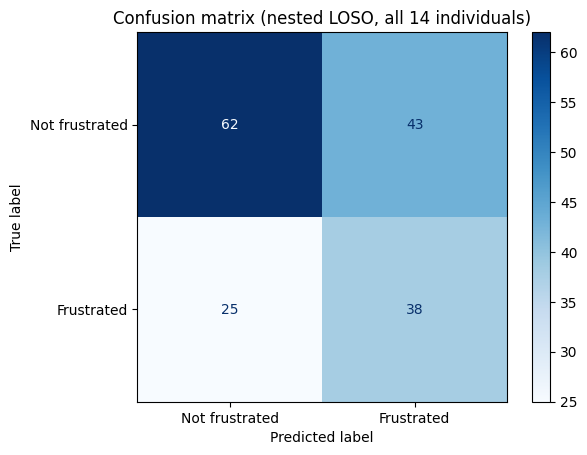

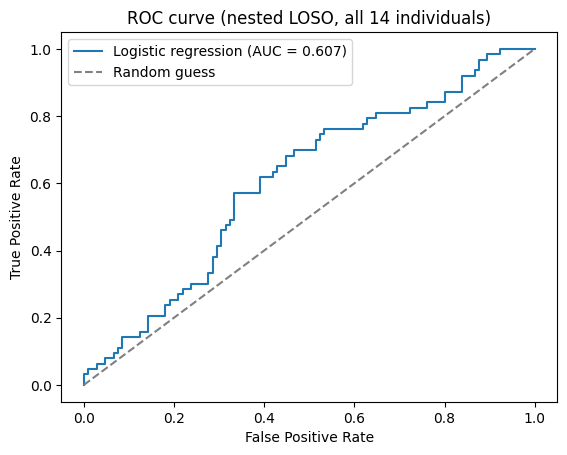

In [9]:
overall_accuracy = accuracy_score(oof_true, oof_pred)
overall_balanced_accuracy = balanced_accuracy_score(oof_true, oof_pred)
overall_auc = roc_auc_score(oof_true, oof_proba)

print(f"Nested LOSO accuracy:          {overall_accuracy:.3f}")
print(f"Nested LOSO balanced accuracy: {overall_balanced_accuracy:.3f}")
print(f"Nested LOSO ROC-AUC:           {overall_auc:.3f}\n")
print("Classification report (all 168 out-of-fold predictions):")
print(classification_report(oof_true, oof_pred, target_names=["Not frustrated", "Frustrated"], zero_division=0))

cm = confusion_matrix(oof_true, oof_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not frustrated", "Frustrated"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix (nested LOSO, all 14 individuals)")
plt.show()

fpr, tpr, _ = roc_curve(oof_true, oof_proba)
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {overall_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (nested LOSO, all 14 individuals)")
plt.legend()
plt.show()

## 7. Per-individual performance

Since each outer fold corresponds to one individual, we also get 14 separate
accuracy/balanced-accuracy scores. This is useful for checking whether performance is fairly
consistent across people, or mostly driven by a couple of easy or hard individuals.

 Individual  best_C best_class_weight  threshold  accuracy  balanced_accuracy
         10   0.001          balanced   0.499013  0.416667           0.227273
         13   0.001          balanced   0.499405  0.416667           0.227273
          6   0.001          balanced   0.499043  0.333333           0.333333
          1   0.001          balanced   0.500166  0.416667           0.388889
          4   0.001          balanced   0.498646  0.416667           0.414286
          5   0.001          balanced   0.499097  0.583333           0.614286
          3   0.001          balanced   0.499639  0.583333           0.625000
         14   0.010          balanced   0.503141  0.666667           0.657143
          2   0.001          balanced   0.499366  0.666667           0.687500
          8   0.001          balanced   0.499433  0.666667           0.687500
          7   0.001          balanced   0.499985  0.750000           0.722222
          9   0.001          balanced   0.499996  0.750000      

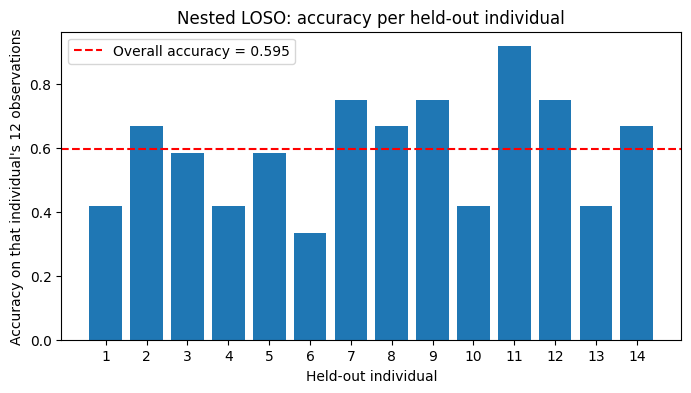

In [10]:
print(fold_df[["Individual", "best_C", "best_class_weight", "threshold", "accuracy", "balanced_accuracy"]]
      .sort_values("balanced_accuracy").to_string(index=False))

print(f"\nMean per-individual accuracy:          {fold_df['accuracy'].mean():.3f} ± {fold_df['accuracy'].std():.3f}")
print(f"Mean per-individual balanced accuracy: {fold_df['balanced_accuracy'].mean():.3f} ± {fold_df['balanced_accuracy'].std():.3f}")

plt.figure(figsize=(8, 4))
plt.bar(fold_df["Individual"].astype(str), fold_df["accuracy"])
plt.axhline(overall_accuracy, color="red", linestyle="--", label=f"Overall accuracy = {overall_accuracy:.3f}")
plt.xlabel("Held-out individual")
plt.ylabel("Accuracy on that individual's 12 observations")
plt.title("Nested LOSO: accuracy per held-out individual")
plt.legend()
plt.show()

## 8. Final model (fit on all individuals) for interpretation

The LOSO loop above gives us 14 slightly different models, one per fold, which is great for
honest performance numbers but awkward for interpretation. So here we fit one more model, on all
14 individuals, using the exact same procedure (inner `StratifiedGroupKFold` + `GridSearchCV` +
balanced-accuracy-maximizing threshold), purely to look at its coefficients. It isn't used for any of the performance
numbers, those came from Section 6.

In [11]:
final_inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

final_grid_search = GridSearchCV(
    pipeline, param_grid, cv=final_inner_cv, scoring="balanced_accuracy", n_jobs=-1,
)
final_grid_search.fit(X, y, groups=groups)
final_model = final_grid_search.best_estimator_

final_oof_proba = cross_val_predict(
    final_model, X, y, groups=groups, cv=final_inner_cv, method="predict_proba"
)[:, 1]
fpr_f, tpr_f, thr_f = roc_curve(y, final_oof_proba)
final_threshold = thr_f[np.argmax(tpr_f - fpr_f)]

print(f"Final model hyperparameters: {final_grid_search.best_params_}")
print(f"Final model threshold (max balanced accuracy, full-data CV): {final_threshold:.3f}")

Final model hyperparameters: {'clf__C': 0.001, 'clf__class_weight': 'balanced'}
Final model threshold (max balanced accuracy, full-data CV): 0.501


## 9. Interpreting the coefficients

Because the features are standardized and one-hot encoded inside the pipeline, we can compare the
coefficients directly to see which heart-rate measures and phase/round indicators matter most. A
positive coefficient means higher values of that feature (or being in that one-hot category) push
the prediction towards "frustrated," and a negative one pushes the other way.

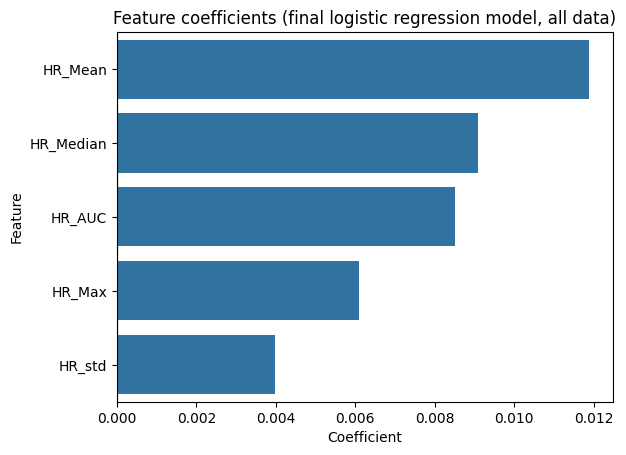

,Feature,Coefficient
0,HR_Mean,0.011889
1,HR_Median,0.009097
4,HR_AUC,0.008516
3,HR_Max,0.006105
2,HR_std,0.003981


In [12]:
preprocessor_fitted = final_model.named_steps["preprocessor"]
clf = final_model.named_steps["clf"]

feature_names_out = [name.split("__", 1)[-1] for name in preprocessor_fitted.get_feature_names_out()]

coef_df = pd.DataFrame({
    "Feature": feature_names_out,
    "Coefficient": clf.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

sns.barplot(data=coef_df, x="Coefficient", y="Feature", orient="h")
plt.title("Feature coefficients (final logistic regression model, all data)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

coef_df

## 10. Save out-of-fold results for model comparison

Finally, we save the pooled out-of-fold predictions (`oof_true`, `oof_pred`, `oof_proba`) and the
per-individual fold metrics to disk, so they can be compared against the ANN in
`model_comparison.ipynb`.

In [13]:
np.savez(
    "results_logreg.npz",
    model_name="Logistic Regression",
    oof_true=oof_true,
    oof_pred=oof_pred,
    oof_proba=oof_proba,
    fold_individual=fold_df["Individual"].to_numpy(),
    fold_accuracy=fold_df["accuracy"].to_numpy(),
    fold_balanced_accuracy=fold_df["balanced_accuracy"].to_numpy(),
)
print("Saved nested-LOSO results to results_logreg.npz")

Saved nested-LOSO results to results_logreg.npz
